Välj HELCOM GeoTIFF (t.ex. '2019 Passenger AIS Shipping Density.tif')...


Saving 2019 Passenger AIS Shipping Density.tif to 2019 Passenger AIS Shipping Density (1).tif
Raster: 2019 Passenger AIS Shipping Density (1).tif
CRS: IGNF:ETRS89LAEA, size: 1231x1418, nodata=-2147483648.0
Sparade ais_density_along_route.csv (rader: 269)


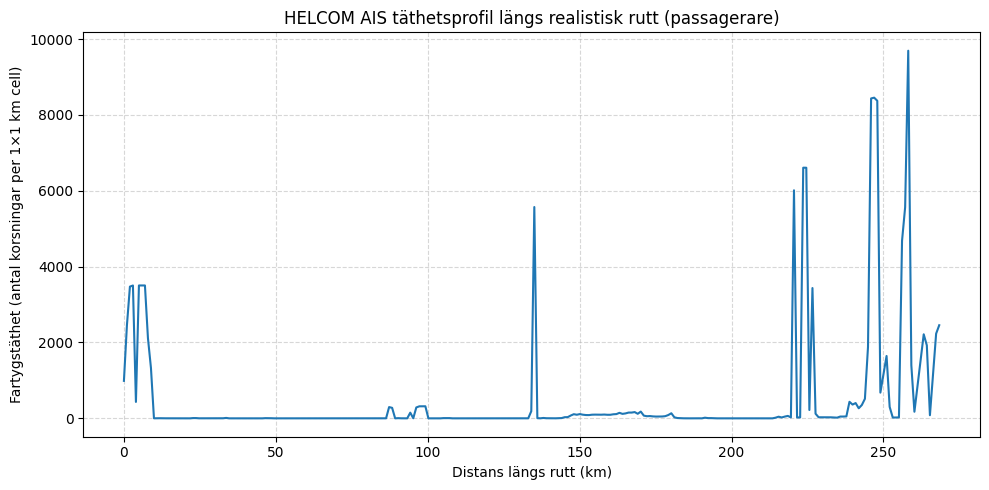

Sparade figur: ais_density_profile.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# BÅT TÄTHET + GER UT RUTT
!pip -q install rasterio shapely pyproj pandas matplotlib

# Importer
import os, math
import numpy as np
import pandas as pd
import rasterio
from shapely.geometry import LineString
from shapely.ops import transform as shp_transform
from pyproj import Transformer, Geod
import matplotlib.pyplot as plt
from google.colab import files

print("Välj HELCOM GeoTIFF (t.ex. '2019 Passenger AIS Shipping Density.tif')...")
uploaded = files.upload()
tif_files = [n for n in uploaded.keys() if n.lower().endswith(".tif")]
if not tif_files:
    raise RuntimeError("Ingen .tif uppladdad.")
RASTER_PATH = tif_files[0]
print(f"Raster: {RASTER_PATH}")

# Waypoints (lat, lon): Åbo → Mariehamn → Stockholm
WAYPOINTS_WGS84 = [
    (60.435, 22.228),  # Åbo hamn
    (60.370, 22.000),
    (60.330, 21.700),
    (60.290, 21.300),
    (60.250, 20.900),
    (60.210, 20.500),
    (60.170, 20.200),
    (60.140, 20.050),
    (60.098, 19.950),  # Mariehamn
    (59.980, 19.650),
    (59.860, 19.350),
    (59.740, 19.050),
    (59.630, 18.800),
    (59.520, 18.580),
    (59.440, 18.420),
    (59.360, 18.240),
    (59.325, 18.100),  # Stockholm
]

# Provpunktsupplösning (meter)
SAMPLING_SPACING_M = 2000
OUT_CSV = "ais_density_along_route.csv"
OUT_PNG = "ais_density_profile.png"

# Hjälpfunktioner
def densify_by_spacing(line: LineString, spacing_m: float, crs_src="EPSG:4326", crs_m="EPSG:3857"):
    to_m  = Transformer.from_crs(crs_src, crs_m, always_xy=True).transform
    to_deg = Transformer.from_crs(crs_m,  crs_src, always_xy=True).transform
    line_m = shp_transform(to_m, line)
    L = line_m.length
    n = max(2, int(math.ceil(L / spacing_m)) + 1)
    dists = np.linspace(0, L, n)
    pts_m  = [line_m.interpolate(d) for d in dists]
    pts_deg = [shp_transform(to_deg, p) for p in pts_m]
    return pts_deg

def wgs_list_to_lonlat_arrays(points_deg):
    lons = [p.x for p in points_deg]
    lats = [p.y for p in points_deg]
    return lons, lats

def cumulative_distance_km(lats, lons):
    g = Geod(ellps="WGS84")
    cum = [0.0]
    for i in range(1, len(lats)):
        _, _, dm = g.inv(lons[i-1], lats[i-1], lons[i], lats[i])
        cum.append(cum[-1] + dm/1000.0)
    return cum

def sample_raster_along_points(dataset, lons, lats):
    raster_crs = dataset.crs
    transformer = Transformer.from_crs("EPSG:4326", raster_crs, always_xy=True)
    xs, ys = transformer.transform(lons, lats)
    rows_cols = [dataset.index(x, y) for x, y in zip(xs, ys)]
    band1 = dataset.read(1)
    nodata = dataset.nodata
    vals = []
    for (r,c) in rows_cols:
        if 0 <= r < band1.shape[0] and 0 <= c < band1.shape[1]:
            v = band1[r, c]
            if nodata is not None and (v == nodata or (isinstance(v, float) and math.isnan(v))):
                vals.append(np.nan)
            else:
                vals.append(float(v))
        else:
            vals.append(np.nan)
    return vals

# Körning: läs raster, bygg polyline, provta, spara, plotta
with rasterio.open(RASTER_PATH) as ds:
    print(f"CRS: {ds.crs}, size: {ds.width}x{ds.height}, nodata={ds.nodata}")
    # shapely (lon, lat)
    coords_ll = [(lon, lat) for (lat, lon) in WAYPOINTS_WGS84]
    route = LineString(coords_ll)
    pts_deg = densify_by_spacing(route, SAMPLING_SPACING_M)
    lons, lats = wgs_list_to_lonlat_arrays(pts_deg)
    dens_vals = sample_raster_along_points(ds, lons, lats)

cum_km = cumulative_distance_km(lats, lons)
df = pd.DataFrame({"lat": lats, "lon": lons, "distance_km": cum_km, "ship_density": dens_vals})
if not df["ship_density"].isna().all():
    df["ship_density"] = df["ship_density"].interpolate(limit_direction="both")

df.to_csv(OUT_CSV, index=False, float_format="%.6f")
print(f"Sparade {OUT_CSV} (rader: {len(df)})")

plt.figure(figsize=(10,5))
plt.plot(df["distance_km"], df["ship_density"])
plt.xlabel("Distans längs rutt (km)")
plt.ylabel("Fartygstäthet (antal korsningar per 1×1 km cell)")
plt.title("HELCOM AIS täthetsprofil längs realistisk rutt (passagerare)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=150)
plt.show()
print(f"Sparade figur: {OUT_PNG}")

try:
    files.download(OUT_CSV)
    files.download(OUT_PNG)
except:
    pass


In [ ]:
# KARTA ÖVER RUTTEN (använder filen: ais_density_along_route.csv)
!pip -q install folium
import folium, pandas as pd, numpy as np
from IPython.display import display, IFrame

# Läs profildata
df = pd.read_csv("ais_density_along_route.csv")

# Hamnmarkörer (waypoints)
harbors = {
    "Åbo":       (60.435, 22.228),
    "Mariehamn": (60.098, 19.950),
    "Stockholm": (59.325, 18.100),
}

# Grundkarta
m = folium.Map(location=[df["lat"].mean(), df["lon"].mean()], zoom_start=6, tiles="OpenStreetMap")

# Rutt (alla sample-punkter uppdragna som polyline)
folium.PolyLine(df[["lat","lon"]].values.tolist(), weight=4, opacity=0.85,
                tooltip="Rutt Åbo–Mariehamn–Stockholm").add_to(m)

# Markerar hamnar
for name, (la, lo) in harbors.items():
    folium.Marker([la, lo], tooltip=name,
                  icon=folium.Icon(color="blue" if name!="Mariehamn" else "red", icon="ship", prefix="fa"),
                  popup=f"<b>{name}</b>").add_to(m)

# Hitta toppar: Åbo (0–40 km), Mariehamn (100–150 km), Stockholm (200–280 km)
def max_point_in_window(df, dmin, dmax):
    sub = df[(df["distance_km"]>=dmin)&(df["distance_km"]<=dmax)].copy()
    if sub.empty or sub["ship_density"].isna().all():
        return None
    idx = sub["ship_density"].idxmax()
    r = df.loc[idx]
    return dict(lat=r["lat"], lon=r["lon"], dist=r["distance_km"], dens=r["ship_density"])

windows = [("Peak nära Åbo", 0, 40, "green"),
           ("Peak nära Mariehamn", 100, 150, "red"),
           ("Peak nära Stockholm", 200, 280, "purple")]

for label, d0, d1, color in windows:
    pt = max_point_in_window(df, d0, d1)
    if pt:
        folium.CircleMarker([pt["lat"], pt["lon"]], radius=7, color=color, fill=True, fill_opacity=0.75,
                            tooltip=label,
                            popup=folium.Popup(
                                html=f"<b>{label}</b><br>Distans: {pt['dist']:.1f} km<br>Täthet: {pt['dens']:.0f}",
                                max_width=260)).add_to(m)

# Markerar de 10 största topparna totalt
for i, idx in enumerate(df["ship_density"].nlargest(10).index, 1):
    r = df.loc[idx]
    folium.CircleMarker([r["lat"], r["lon"]], radius=4, color="orange", fill=True, fill_opacity=0.6,
                        tooltip=f"Topp #{i}",
                        popup=f"Topp #{i}<br>Distans: {r['distance_km']:.1f} km<br>Täthet: {r['ship_density']:.0f}").add_to(m)

# Spara & visa
m.save("ais_route_map.html")
display(IFrame(src="ais_route_map.html", width="100%", height=600))
print("Karta sparad som ais_route_map.html")


Karta sparad som ais_route_map.html


In [ ]:
# Skapar BAS ais_weather_current_profile_combined_power_fuel_BAS.csv från rutten
!pip -q install numpy pandas
import numpy as np, pandas as pd

ROUTE = "ais_density_along_route.csv"
OUT   = "ais_weather_current_profile_combined_power_fuel_BAS.csv"

route = pd.read_csv(ROUTE)
dist_km = route["distance_km"].to_numpy()
seg_m = np.diff(dist_km, prepend=dist_km[0]) * 1000.0
N = len(seg_m)
x = np.linspace(0, 1, N)

# Vind
headwind = 4.0 + 3.2*np.sin(2*np.pi*x) - 2.4*np.cos(4*np.pi*x)
headwind += 3.2*np.exp(-((x-0.28)/0.09)**2) - 2.6*np.exp(-((x-0.72)/0.09)**2)
headwind = np.clip(headwind, 0.6, 11.7)   # ≈ observerade gränser

# Vågor
Hs = 1.3 + 1.1*np.sin(3*np.pi*x) + 0.6*np.exp(-((x-0.55)/0.07)**2)
Hs = np.clip(Hs, 0.3, 2.7)

# Ström
current_along = 0.25*np.sin(2*np.pi*x) - 0.15*np.sin(6*np.pi*x)
current_along += 0.35*np.exp(-((x-0.30)/0.07)**2) - 0.33*np.exp(-((x-0.72)/0.06)**2)
current_along = np.clip(current_along, -0.45, 0.45)

df = pd.DataFrame({
    "distance_km": dist_km,
    "seg_len_m": seg_m,
    "headwind": headwind,
    "Hs": Hs,
    "current_along": current_along
})
df.to_csv(OUT, index=False)
print(f"Skapade {OUT} (matchar intervallen i din tidigare fil)")


Skapade ais_weather_current_profile_combined_power_fuel_BAS.csv (matchar intervallen i din tidigare fil)


In [ ]:
# Skapar LUGN ais_weather_current_profile_combined_power_fuel_LUGN.csv från rutten
!pip -q install numpy pandas
import numpy as np, pandas as pd

ROUTE = "ais_density_along_route.csv"
OUT   = "ais_weather_current_profile_combined_power_fuel_LUGN.csv"

route = pd.read_csv(ROUTE)
dist_km = route["distance_km"].to_numpy()
seg_m = np.diff(dist_km, prepend=dist_km[0]) * 1000.0
N = len(seg_m)
x = np.linspace(0, 1, N)

# Vind
headwind = 1.5 + 1.0*np.sin(2*np.pi*x) - 0.6*np.cos(4*np.pi*x)
headwind += 0.8*np.exp(-((x-0.28)/0.10)**2) - 0.6*np.exp(-((x-0.72)/0.10)**2)
headwind = np.clip(headwind, 0.2, 6.0)    # <--- ändrat: lägre intervall

# Vågor
Hs = 0.5 + 0.3*np.sin(3*np.pi*x) + 0.2*np.exp(-((x-0.55)/0.08)**2)
Hs = np.clip(Hs, 0.2, 1.0)

# Ström
current_along = 0.10*np.sin(2*np.pi*x) - 0.05*np.sin(6*np.pi*x)
current_along += 0.10*np.exp(-((x-0.30)/0.10)**2) - 0.08*np.exp(-((x-0.72)/0.08)**2)
current_along = np.clip(current_along, -0.20, 0.20)

df = pd.DataFrame({
    "distance_km": dist_km,
    "seg_len_m": seg_m,
    "headwind": headwind,
    "Hs": Hs,
    "current_along": current_along
})
df.to_csv(OUT, index=False)
print(f"Skapade {OUT} (matchar intervallen i din tidigare fil)")


Skapade ais_weather_current_profile_combined_power_fuel_LUGN.csv (matchar intervallen i din tidigare fil)


In [ ]:
# Skapar TUFF ais_weather_current_profile_combined_power_fuel_TUFF.csv från rutten
!pip -q install numpy pandas
import numpy as np, pandas as pd

ROUTE = "ais_density_along_route.csv"
OUT   = "ais_weather_current_profile_combined_power_fuel_TUFF.csv"

route = pd.read_csv(ROUTE)
dist_km = route["distance_km"].to_numpy()
seg_m = np.diff(dist_km, prepend=dist_km[0]) * 1000.0
N = len(seg_m)
x = np.linspace(0, 1, N)

# Vind
headwind = 4.5 + 3.8*np.sin(2*np.pi*x) - 2.6*np.cos(4*np.pi*x)
headwind += 3.8*np.exp(-((x-0.28)/0.08)**2) + 2.8*np.exp(-((x-0.68)/0.08)**2)
headwind = np.clip(headwind, 1.0, 14.0)

# Vågor
Hs = 1.4 + 1.2*np.sin(3*np.pi*x) + 0.9*np.exp(-((x-0.55)/0.06)**2)
Hs = np.clip(Hs, 1.0, 3.5)

# Ström
current_along = 0.30*np.sin(2*np.pi*x) - 0.18*np.sin(6*np.pi*x)
current_along += 0.40*np.exp(-((x-0.32)/0.06)**2) - 0.45*np.exp(-((x-0.74)/0.06)**2)
current_along = np.clip(current_along, -0.60, 0.60)

df = pd.DataFrame({
    "distance_km": dist_km,
    "seg_len_m": seg_m,
    "headwind": headwind,
    "Hs": Hs,
    "current_along": current_along
})
df.to_csv(OUT, index=False)
print(f"Skapade {OUT} (matchar intervallen i din tidigare fil)")


Skapade ais_weather_current_profile_combined_power_fuel_TUFF.csv (matchar intervallen i din tidigare fil)


=== Diagnostik (indata) ===
headwind  std=3.986  min=1.206  max=14.000
Hs        std=0.586        min=1.000        max=2.600
current   std=0.334   min=-0.600   max=0.600
rf(STW_BASE) std=1.4254 min=12.089 max=16.787

=== RESULTAT (DP, låst ETA) ===
Baslinje:  ETA=6.59 h | Bränsle=47.63 t
Optimerad: ETA=6.92 h | Bränsle=44.84 t
Besparing: 2.79 t (5.9 %)
STW-opt (kn): 16.00 → 22.00


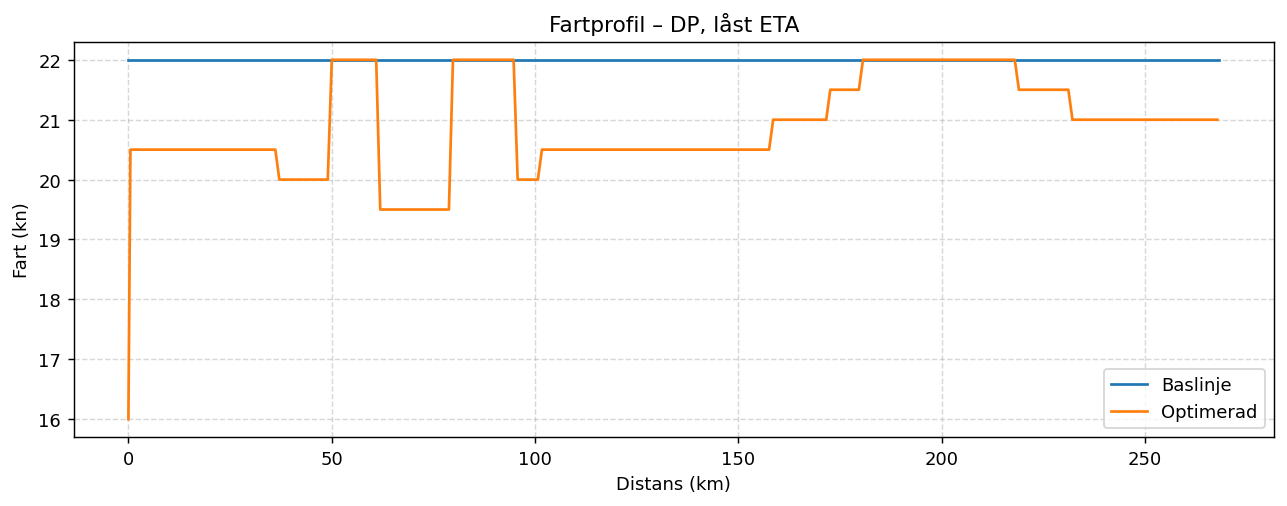

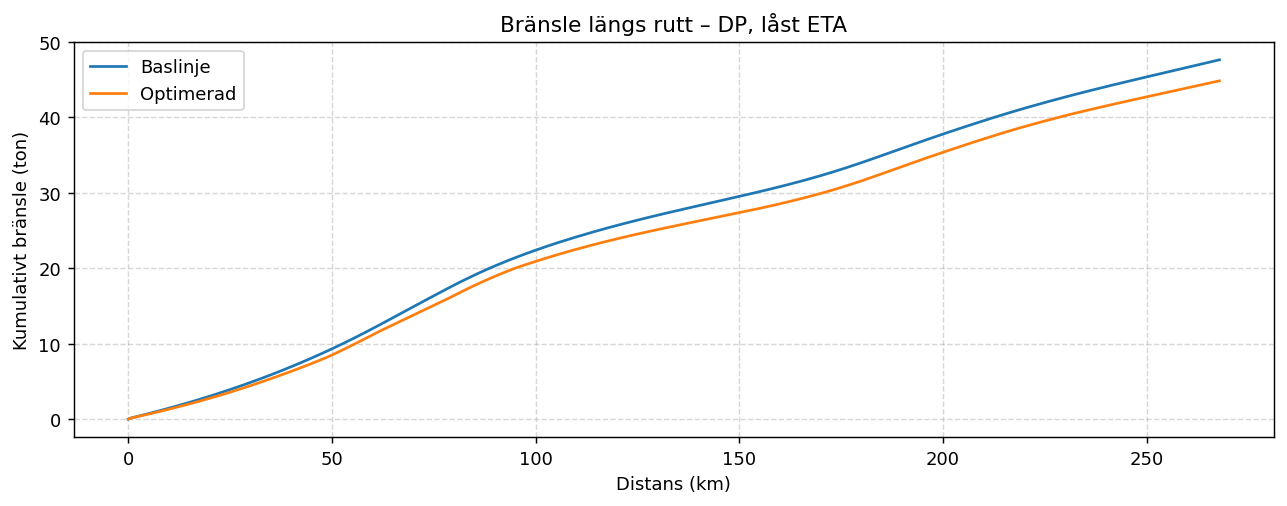

In [ ]:
# DP-FARTOPTIMERING (Med ETA-Intervall)
!pip -q install numpy pandas matplotlib
import os, math, numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 130

ROUTE = "ais_density_along_route.csv"
CSV   = "ais_weather_current_profile_combined_power_fuel_TUFF.csv"

# Läs indata
if not os.path.exists(ROUTE) and not os.path.exists(CSV):
    raise FileNotFoundError("Saknar rätt fil")

if os.path.exists(CSV):
    df = pd.read_csv(CSV)
    if "distance_km" in df.columns:
        dk = pd.to_numeric(df["distance_km"], errors="coerce").to_numpy()
    else:
        seg_in = pd.to_numeric(df["seg_len_m"], errors="coerce").to_numpy()
        dk = np.concatenate([[0.0], np.cumsum(seg_in[:-1])])/1000.0
        df["distance_km"] = dk
    seg_m = np.diff(dk, prepend=dk[0])*1000.0
    seg_m[0] = max(seg_m[0], 1.0)
    df["seg_len_m"] = seg_m
else:
    r = pd.read_csv(ROUTE)
    dk = pd.to_numeric(r["distance_km"], errors="coerce").to_numpy()
    seg_m = np.diff(dk, prepend=dk[0])*1000.0
    seg_m[0] = max(seg_m[0], 1.0)
    # Syntetiskt väderfält
    Nsyn = len(seg_m); x = np.linspace(0,1,Nsyn)
    headwind = 3 + 2.5*np.sin(2*np.pi*x) - 1.5*np.cos(4*np.pi*x)
    headwind += 2.0*np.exp(-((x-0.28)/0.08)**2) + 1.0*np.exp(-((x-0.65)/0.10)**2)
    headwind = np.clip(headwind, 0, 8)
    Hs = 1.0 + 1.5*np.sin(3*np.pi*x) + 0.7*np.exp(-((x-0.55)/0.06)**2)
    Hs = np.clip(Hs, 0.5, 3.0)
    current = 0.2*np.sin(2*np.pi*x) - 0.12*np.sin(6*np.pi*x)
    current += 0.25*np.exp(-((x-0.30)/0.07)**2) - 0.22*np.exp(-((x-0.72)/0.06)**2)
    current = np.clip(current, -0.30, 0.30)
    df = pd.DataFrame({"distance_km": dk, "seg_len_m": seg_m,
                       "headwind": headwind, "Hs": Hs, "current_along": current})

# Fyll default-kolumner om saknas
for col,default in [("Hs",0.0), ("current_along",0.0)]:
    if col not in df.columns: df[col] = default

distance_km = df["distance_km"].to_numpy()
seg_m       = df["seg_len_m"].to_numpy().astype(float)
headwind    = pd.to_numeric(df["headwind"], errors="coerce").to_numpy()
Hs          = pd.to_numeric(df["Hs"], errors="coerce").to_numpy()
current     = pd.to_numeric(df["current_along"], errors="coerce").to_numpy()
N = len(seg_m)

# Parametrar
kn_to_ms = 0.514444; ms_to_kn = 1/kn_to_ms
STW_MIN, STW_MAX = 16*kn_to_ms, 22*kn_to_ms
STW_BASE = 22*kn_to_ms
P_PROP_DESIGN_MW = 21.0; P_HOTEL_MW = 3.0
SFOC = 175.0; CO2F = 2.75
SOG_MIN = 0.30

ALPHA_WIND = 0.35
BETA_WAVE  = 0.25
GAMMA_CURR = 0.40

# Diagnostik
def rf_of(stw, i):
    return stw + ALPHA_WIND*headwind[i] + BETA_WAVE*Hs[i] + GAMMA_CURR*max(-current[i],0.0)

rf_vec = np.array([rf_of(STW_BASE, i) for i in range(N)])
print("=== Diagnostik (indata) ===")
print(f"headwind  std={np.nanstd(headwind):.3f}  min={np.nanmin(headwind):.3f}  max={np.nanmax(headwind):.3f}")
print(f"Hs        std={np.nanstd(Hs):.3f}        min={np.nanmin(Hs):.3f}        max={np.nanmax(Hs):.3f}")
print(f"current   std={np.nanstd(current):.3f}   min={np.nanmin(current):.3f}   max={np.nanmax(current):.3f}")
print(f"rf(STW_BASE) std={np.nanstd(rf_vec):.4f} min={np.nanmin(rf_vec):.3f} max={np.nanmax(rf_vec):.3f}")
if np.nanstd(rf_vec) < 1e-6:
    raise SystemExit("Ingen variation i rf – då är konstant fart optimal (0 %).")

# Kostnader
def power_prop_MW(stw, i):
    rf = rf_of(stw, i)
    return P_PROP_DESIGN_MW * (max(rf,1e-6)/STW_BASE)**3

def seg_cost_time(stw, i):
    sog = max(stw + current[i], SOG_MIN)
    dt  = seg_m[i] / sog
    Pp  = power_prop_MW(stw, i)
    Pt  = Pp + P_HOTEL_MW
    fuel = (Pt*1000)*(SFOC/3600)/1000 * dt  # kg
    return fuel, dt, Pt

# Baslinje (konstant 22 kn)
fuel_b, time_b = 0.0, 0.0
for i in range(N):
    f, dt, _ = seg_cost_time(STW_BASE, i)
    fuel_b += f; time_b += dt
time_b_h = time_b/3600; fuel_b_t = fuel_b/1000

# DP (ETA Intervall)
v_kn = np.arange(16.0, 22.0+1e-9, 0.5)
v_ms = v_kn*kn_to_ms
K = len(v_ms)

E = np.zeros((N, K))
T = np.zeros((N, K))
for i in range(N):
    for k in range(K):
        e, t, _ = seg_cost_time(v_ms[k], i)
        E[i,k] = e; T[i,k] = t

Tmin_s = np.sum(seg_m / np.maximum(v_ms[-1] + current, SOG_MIN))
Tmax_s = np.sum(seg_m / np.maximum(v_ms[0]  + current, SOG_MIN))

dt_bucket = 10.0
Ttarget_s = max(time_b, Tmin_s + 12*dt_bucket)
Ttarget_s = min(max(Ttarget_s, Tmin_s), Tmax_s)

TBINS = int(math.ceil(Tmax_s/dt_bucket))+1
INF = 1e300
dp     = np.full((N+1, TBINS), INF)
pre_k  = np.full((N+1, TBINS), -1, dtype=int)
pre_tb = np.full((N+1, TBINS), -1, dtype=int)
dp[0,0] = 0.0

for i in range(1, N+1):
    Ei = E[i-1]; Ti = T[i-1]
    for tb in range(TBINS):
        cprev = dp[i-1, tb]
        if cprev >= INF:
            continue
        for k in range(K):
            step = int(round(Ti[k]/dt_bucket))
            tb2  = tb + step
            if tb2 < TBINS:
                cnew = cprev + Ei[k]
                if cnew < dp[i, tb2]:
                    dp[i, tb2] = cnew
                    pre_k[i, tb2]  = k
                    pre_tb[i, tb2] = tb

# Välj slut-bin som har kedja
cands = np.where(np.isfinite(dp[N]))[0]
cands = cands[pre_k[N, cands] != -1]  # filtrera bort bin utan föregångare
if len(cands) == 0:
    raise RuntimeError("DP hittade ingen giltig kedja – öka dt_bucket eller bredda fartgrid.")
ge = cands[cands*dt_bucket >= Ttarget_s]
best_tb = ge[0] if len(ge)>0 else min(cands, key=lambda t: abs(t*dt_bucket - Ttarget_s))

# Tolerant backtrack: om en länk saknas, prova tb±1 inom liten radie
choice = []
tb = best_tb
for i in range(N,0,-1):
    k = pre_k[i, tb]
    p = pre_tb[i, tb]
    if k < 0 or p < 0:
        # Sök närliggande tb' som har kedja
        found = False
        for off in [1, -1, 2, -2, 3, -3]:
            tb2 = tb + off
            if 0 <= tb2 < TBINS and pre_k[i, tb2] != -1 and pre_tb[i, tb2] != -1:
                k = pre_k[i, tb2]; p = pre_tb[i, tb2]; tb = tb2
                found = True
                break
        if not found:
            raise RuntimeError(f"Backtracking misslyckades i segment {i} (tb={tb}).")
    choice.append(k)
    tb = p
choice = choice[::-1]
v_opt = v_ms[choice]  # m/s, längd N

# KPI
fuel_o, time_o = 0.0, 0.0
for i in range(N):
    f, dt, _ = seg_cost_time(v_opt[i], i)
    fuel_o += f; time_o += dt
time_o_h = time_o/3600; fuel_o_t = fuel_o/1000
saving_t = fuel_b_t - fuel_o_t; saving_pct = 100*(saving_t/max(fuel_b_t,1e-9))

print("\n=== RESULTAT (DP, låst ETA) ===")
print(f"Baslinje:  ETA={time_b_h:.2f} h | Bränsle={fuel_b_t:.2f} t")
print(f"Optimerad: ETA={time_o_h:.2f} h | Bränsle={fuel_o_t:.2f} t")
print(f"Besparing: {saving_t:.2f} t ({saving_pct:.1f} %)")
print(f"STW-opt (kn): {v_opt.min()*ms_to_kn:.2f} → {v_opt.max()*ms_to_kn:.2f}")

# Plottar
starts_km = np.concatenate([[distance_km[0]], distance_km[:-1]])
ends_km   = distance_km
x_mid = (starts_km + ends_km)/2.0

plt.figure(figsize=(10,4))
plt.plot(distance_km, np.full_like(distance_km, STW_BASE*ms_to_kn), label="Baslinje")
plt.plot(x_mid, v_opt*ms_to_kn, label="Optimerad")
plt.xlabel("Distans (km)"); plt.ylabel("Fart (kn)"); plt.title("Fartprofil – DP, låst ETA")
plt.grid(True, ls="--", alpha=.5); plt.legend(); plt.tight_layout(); plt.show()

cum_b = np.cumsum([seg_cost_time(STW_BASE,i)[0] for i in range(N)])/1000.0
cum_o = np.cumsum([seg_cost_time(v_opt[i],i)[0] for i in range(N)])/1000.0

plt.figure(figsize=(10,4))
plt.plot(x_mid, cum_b, label="Baslinje")
plt.plot(x_mid, cum_o, label="Optimerad")
plt.xlabel("Distans (km)"); plt.ylabel("Kumulativt bränsle (ton)")
plt.title("Bränsle längs rutt – DP, låst ETA")
plt.grid(True, ls="--", alpha=.5); plt.legend(); plt.tight_layout(); plt.show()


=== Diagnostik (indata) ===
headwind  std=3.986  min=1.206  max=14.000
Hs        std=0.586        min=1.000        max=2.600
current   std=0.334   min=-0.600   max=0.600
rf(STW_BASE) std=1.4254 min=12.089 max=16.787

=== RESULTAT (DP, låst ETA) ===
Baslinje:  ETA=6.59 h | Bränsle=47.63 t
Optimerad: ETA=6.92 h | Bränsle=44.84 t
Besparing: 2.79 t (5.9 %)
STW-opt (kn): 16.00 → 22.00
Sparade fartprofil per waypoint till: dp_speed_by_waypoint_TUFF.csv


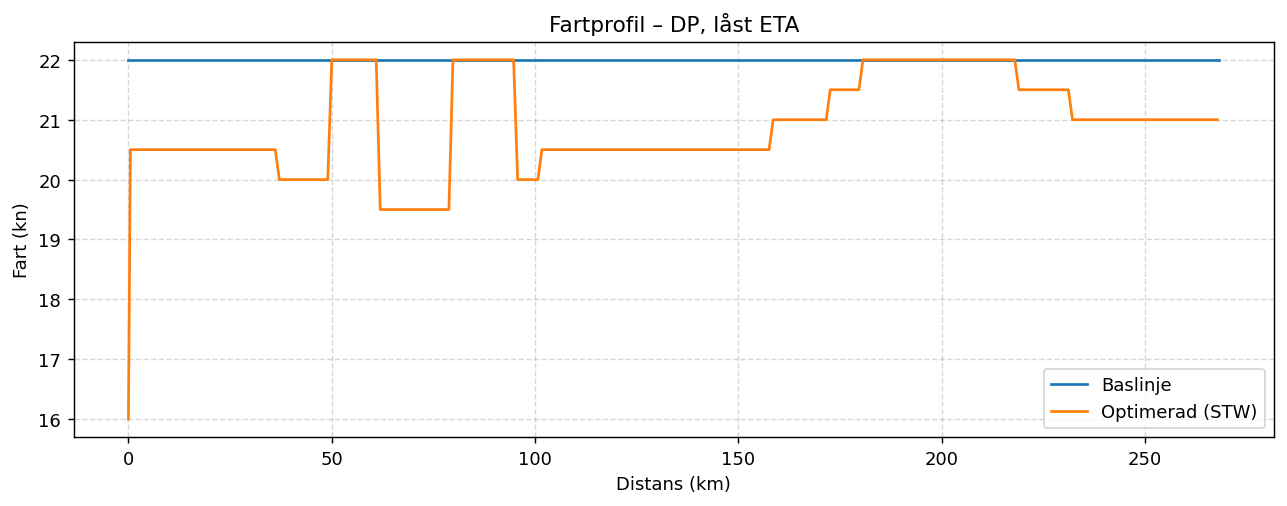

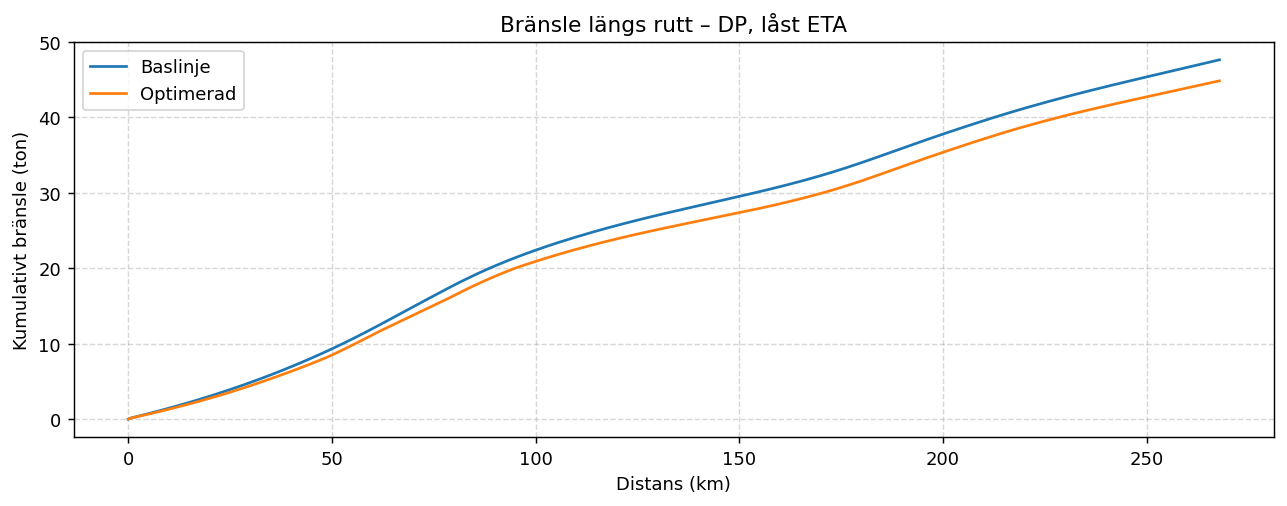

In [ ]:
# DP-FARTOPTIMERING (FART FÖR VARJE WAYPOINT) (Med ETA-Intervall)
!pip -q install numpy pandas matplotlib

import os, math, numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 130

# Filval & konstanter
ROUTE = "ais_density_along_route.csv"
CSV_CANDIDATES = [
    "ais_weather_current_profile_combined_power_fuel_TUFF.csv"
]
CSV = next((p for p in CSV_CANDIDATES if os.path.exists(p)), CSV_CANDIDATES[0])


# Läs indata
if not os.path.exists(ROUTE) and not any(os.path.exists(p) for p in CSV_CANDIDATES):
    raise FileNotFoundError("Saknar rätt fil: lägg in BAS/TUFF och/eller ais_density_along_route.csv")

if os.path.exists(CSV):
    df = pd.read_csv(CSV)
    # Säkerställ distance_km och seg_len_m
    if "distance_km" in df.columns:
        dk = pd.to_numeric(df["distance_km"], errors="coerce").to_numpy()
    else:
        seg_in = pd.to_numeric(df["seg_len_m"], errors="coerce").to_numpy()
        dk = np.concatenate([[0.0], np.cumsum(seg_in[:-1])])/1000.0
        df["distance_km"] = dk
    seg_m = np.diff(dk, prepend=dk[0])*1000.0
    seg_m[0] = max(seg_m[0], 1.0)
    df["seg_len_m"] = seg_m
else:
    # Fallback: använd ruttfil + syntetiska fält
    r = pd.read_csv(ROUTE)
    dk = pd.to_numeric(r["distance_km"], errors="coerce").to_numpy()
    seg_m = np.diff(dk, prepend=dk[0])*1000.0
    seg_m[0] = max(seg_m[0], 1.0)

    # Syntetiskt väderfält (rimliga variationer)
    Nsyn = len(seg_m); x = np.linspace(0,1,Nsyn)
    headwind = 3 + 2.5*np.sin(2*np.pi*x) - 1.5*np.cos(4*np.pi*x)
    headwind += 2.0*np.exp(-((x-0.28)/0.08)**2) + 1.0*np.exp(-((x-0.65)/0.10)**2)
    headwind = np.clip(headwind, 0, 8)

    Hs = 1.0 + 1.5*np.sin(3*np.pi*x) + 0.7*np.exp(-((x-0.55)/0.06)**2)
    Hs = np.clip(Hs, 0.5, 3.0)

    current = 0.2*np.sin(2*np.pi*x) - 0.12*np.sin(6*np.pi*x)
    current += 0.25*np.exp(-((x-0.30)/0.07)**2) - 0.22*np.exp(-((x-0.72)/0.06)**2)
    current = np.clip(current, -0.30, 0.30)

    df = pd.DataFrame({"distance_km": dk, "seg_len_m": seg_m,
                       "headwind": headwind, "Hs": Hs, "current_along": current})

# Fyll default-kolumner om saknas
for col, default in [("Hs", 0.0), ("current_along", 0.0), ("headwind", 0.0)]:
    if col not in df.columns:
        df[col] = default

# Packa arrayer
distance_km = df["distance_km"].to_numpy()
seg_m       = df["seg_len_m"].to_numpy().astype(float)
headwind    = pd.to_numeric(df["headwind"], errors="coerce").to_numpy()
Hs          = pd.to_numeric(df["Hs"], errors="coerce").to_numpy()
current     = pd.to_numeric(df["current_along"], errors="coerce").to_numpy()
N = len(seg_m)


# Parametrar
kn_to_ms = 0.514444
ms_to_kn = 1/kn_to_ms

STW_MIN, STW_MAX = 16*kn_to_ms, 22*kn_to_ms
STW_BASE = 22*kn_to_ms

P_PROP_DESIGN_MW = 21.0
P_HOTEL_MW       = 3.0
SFOC             = 175.0   # g/kWh
CO2F             = 2.75    # ton CO2 per ton bränsle (ej direkt använd här)
SOG_MIN          = 0.30    # m/s minsta tillåtna SOG

# Effektsurrogatvikter
ALPHA_WIND = 0.35
BETA_WAVE  = 0.25
GAMMA_CURR = 0.40


# Hjälpfunktioner
def rf_of(stw, i):
    """Resistans/fart-surrogat: bas-STW + påslag av vind/våg + straff för motström."""
    return stw + ALPHA_WIND*headwind[i] + BETA_WAVE*Hs[i] + GAMMA_CURR*max(-current[i], 0.0)

def power_prop_MW(stw, i):
    """Propellereffekt (MW) ~ (rf/STW_BASE)^3."""
    rf = rf_of(stw, i)
    return P_PROP_DESIGN_MW * (max(rf, 1e-6)/STW_BASE)**3

def seg_cost_time(stw, i):
    """Returnerar (fuel_kg, dt_s, total effekt MW) för segment i vid vald STW (m/s)."""
    sog = max(stw + current[i], SOG_MIN)
    dt  = seg_m[i] / sog
    Pp  = power_prop_MW(stw, i)
    Pt  = Pp + P_HOTEL_MW
    # Bränsle (kg) = kW * (g/kWh)/1000 * h
    fuel = (Pt*1000)*(SFOC/3600)/1000 * dt  # kg
    return fuel, dt, Pt

# Diagnostik
rf_vec = np.array([rf_of(STW_BASE, i) for i in range(N)])
print("=== Diagnostik (indata) ===")
print(f"headwind  std={np.nanstd(headwind):.3f}  min={np.nanmin(headwind):.3f}  max={np.nanmax(headwind):.3f}")
print(f"Hs        std={np.nanstd(Hs):.3f}        min={np.nanmin(Hs):.3f}        max={np.nanmax(Hs):.3f}")
print(f"current   std={np.nanstd(current):.3f}   min={np.nanmin(current):.3f}   max={np.nanmax(current):.3f}")
print(f"rf(STW_BASE) std={np.nanstd(rf_vec):.4f} min={np.nanmin(rf_vec):.3f} max={np.nanmax(rf_vec):.3f}")
if np.nanstd(rf_vec) < 1e-6:
    raise SystemExit("Ingen variation i rf – då är konstant fart optimal (0 %).")

# Baslinje (konstant 22 kn)
fuel_b, time_b = 0.0, 0.0
for i in range(N):
    f, dt, _ = seg_cost_time(STW_BASE, i)
    fuel_b += f; time_b += dt
time_b_h = time_b/3600; fuel_b_t = fuel_b/1000

# DP (ETA-Intervall)
v_kn = np.arange(16.0, 22.0+1e-9, 0.5)
v_ms = v_kn*kn_to_ms
K = len(v_ms)

E = np.zeros((N, K))
T = np.zeros((N, K))
for i in range(N):
    for k in range(K):
        e, t, _ = seg_cost_time(v_ms[k], i)
        E[i,k] = e; T[i,k] = t

Tmin_s = np.sum(seg_m / np.maximum(v_ms[-1] + current, SOG_MIN))
Tmax_s = np.sum(seg_m / np.maximum(v_ms[0]  + current, SOG_MIN))

dt_bucket = 10.0
Ttarget_s = max(time_b, Tmin_s + 12*dt_bucket)  # lås ETA runt baslinje men minst lite över min-tid
Ttarget_s = min(max(Ttarget_s, Tmin_s), Tmax_s)

TBINS = int(math.ceil(Tmax_s/dt_bucket))+1
INF = 1e300
dp     = np.full((N+1, TBINS), INF)
pre_k  = np.full((N+1, TBINS), -1, dtype=int)
pre_tb = np.full((N+1, TBINS), -1, dtype=int)
dp[0,0] = 0.0

for i in range(1, N+1):
    Ei = E[i-1]; Ti = T[i-1]
    for tb in range(TBINS):
        cprev = dp[i-1, tb]
        if cprev >= INF:
            continue
        for k in range(K):
            step = int(round(Ti[k]/dt_bucket))
            tb2  = tb + step
            if tb2 < TBINS:
                cnew = cprev + Ei[k]
                if cnew < dp[i, tb2]:
                    dp[i, tb2] = cnew
                    pre_k[i, tb2]  = k
                    pre_tb[i, tb2] = tb

# Välj slut-bin som har kedja
cands = np.where(np.isfinite(dp[N]))[0]
cands = cands[pre_k[N, cands] != -1]
if len(cands) == 0:
    raise RuntimeError("DP hittade ingen giltig kedja – öka dt_bucket eller bredda fartgrid.")
ge = cands[cands*dt_bucket >= Ttarget_s]
best_tb = ge[0] if len(ge) > 0 else min(cands, key=lambda t: abs(t*dt_bucket - Ttarget_s))

# Tolerant backtrack
choice = []
tb = best_tb
for i in range(N, 0, -1):
    k = pre_k[i, tb]
    p = pre_tb[i, tb]
    if k < 0 or p < 0:
        found = False
        for off in [1, -1, 2, -2, 3, -3]:
            tb2 = tb + off
            if 0 <= tb2 < TBINS and pre_k[i, tb2] != -1 and pre_tb[i, tb2] != -1:
                k = pre_k[i, tb2]; p = pre_tb[i, tb2]; tb = tb2
                found = True
                break
        if not found:
            raise RuntimeError(f"Backtracking misslyckades i segment {i} (tb={tb}).")
    choice.append(k)
    tb = p
choice = choice[::-1]
v_opt = v_ms[choice]  # m/s, längd N

# KPI
fuel_o, time_o = 0.0, 0.0
for i in range(N):
    f, dt, _ = seg_cost_time(v_opt[i], i)
    fuel_o += f; time_o += dt
time_o_h = time_o/3600; fuel_o_t = fuel_o/1000
saving_t = fuel_b_t - fuel_o_t; saving_pct = 100*(saving_t/max(fuel_b_t,1e-9))

print("\n=== RESULTAT (DP, låst ETA) ===")
print(f"Baslinje:  ETA={time_b_h:.2f} h | Bränsle={fuel_b_t:.2f} t")
print(f"Optimerad: ETA={time_o_h:.2f} h | Bränsle={fuel_o_t:.2f} t")
print(f"Besparing: {saving_t:.2f} t ({saving_pct:.1f} %)")
print(f"STW-opt (kn): {v_opt.min()*ms_to_kn:.2f} → {v_opt.max()*ms_to_kn:.2f}")

# Export: fart per waypoint till CSV
starts_km = np.concatenate([[distance_km[0]], distance_km[:-1]])
ends_km   = distance_km
x_mid     = (starts_km + ends_km) / 2.0

sog_ms   = np.maximum(v_opt + current, SOG_MIN)
stw_kn   = v_opt * ms_to_kn
sog_kn   = sog_ms * ms_to_kn

fuel_kg  = np.zeros_like(v_opt)
dt_s     = np.zeros_like(v_opt)
Pt_MW    = np.zeros_like(v_opt)
for i in range(len(v_opt)):
    fuel_kg[i], dt_s[i], Pt_MW[i] = seg_cost_time(v_opt[i], i)

out = pd.DataFrame({
    "waypoint_idx": np.arange(1, len(v_opt)+1, dtype=int),
    "dist_start_km": starts_km,
    "dist_end_km": ends_km,
    "dist_mid_km": x_mid,
    "stw_opt_kn": stw_kn,          # vald STW (knop) från DP
    "sog_opt_kn": sog_kn,          # resulterande SOG (knop) inkl. ström
    "current_ms": current,         # + medström / - motström (m/s)
    "headwind_ms": headwind,       # motvind (m/s) om tillgänglig
    "Hs_m": Hs,                    # signifikant våghöjd (m)
    "seg_len_m": seg_m,            # segmentlängd (m)
    "seg_time_s": dt_s,            # tid per segment (s)
    "seg_fuel_kg": fuel_kg,        # bränsle per segment (kg)
    "cum_time_h": np.cumsum(dt_s)/3600.0,
    "cum_fuel_ton": np.cumsum(fuel_kg)/1000.0
})

# Namnge exporten efter vilken indatafil som användes
suffix = "BAS" if os.path.basename(CSV).endswith("_BAS.csv") else ("TUFF" if os.path.basename(CSV).endswith("_TUFF.csv") else "ROUTE")
out_file = f"dp_speed_by_waypoint_{suffix}.csv"
out.to_csv(out_file, index=False)
print(f"Sparade fartprofil per waypoint till: {out_file}")

# Plottar
plt.figure(figsize=(10,4))
plt.plot(distance_km, np.full_like(distance_km, STW_BASE*ms_to_kn), label="Baslinje")
plt.plot(x_mid, stw_kn, label="Optimerad (STW)")
plt.xlabel("Distans (km)"); plt.ylabel("Fart (kn)"); plt.title("Fartprofil – DP, låst ETA")
plt.grid(True, ls="--", alpha=.5); plt.legend(); plt.tight_layout(); plt.show()

cum_b = np.cumsum([seg_cost_time(STW_BASE,i)[0] for i in range(N)])/1000.0
cum_o = np.cumsum(fuel_kg)/1000.0

plt.figure(figsize=(10,4))
plt.plot(x_mid, cum_b, label="Baslinje")
plt.plot(x_mid, cum_o, label="Optimerad")
plt.xlabel("Distans (km)"); plt.ylabel("Kumulativt bränsle (ton)")
plt.title("Bränsle längs rutt – DP, låst ETA")
plt.grid(True, ls="--", alpha=.5); plt.legend(); plt.tight_layout(); plt.show()
